# Logistic Regression Project on Social Network Ads Dataset
Applying Logistic Regression on a different dataset using the same methodology as Lab 7.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline

## Read the Data

In [2]:
ads = pd.read_csv('Social_Network_Ads.csv')
ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


## Check out the Data

In [3]:
ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [4]:
ads.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## Exploratory Data Analysis

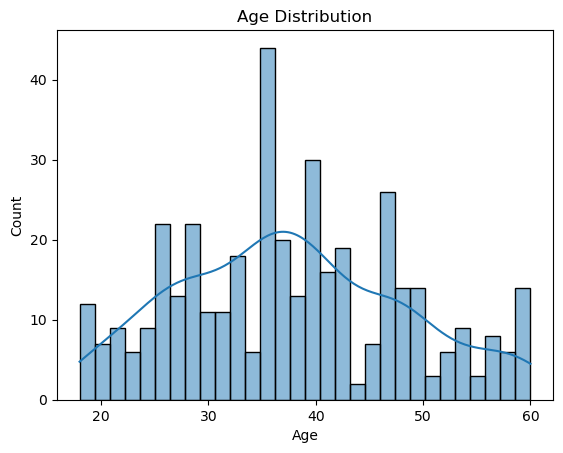

In [5]:
sns.histplot(ads['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

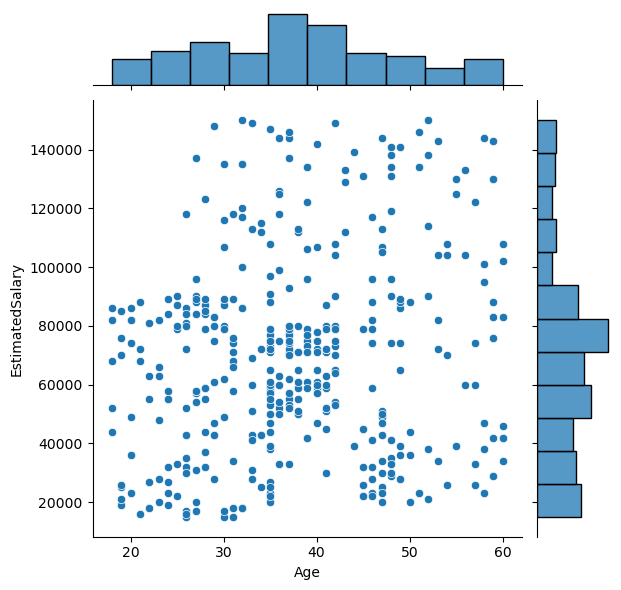

In [6]:
sns.jointplot(x='Age', y='EstimatedSalary', data=ads)
plt.show()

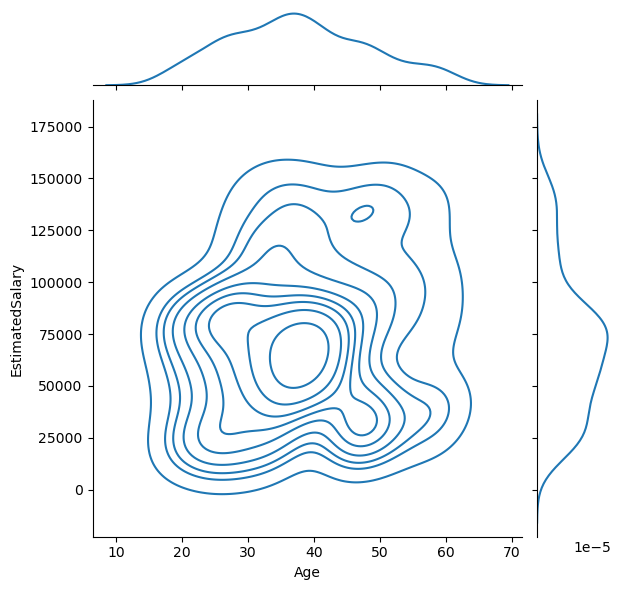

In [7]:
sns.jointplot(x='Age', y='EstimatedSalary', data=ads, kind='kde')
plt.show()

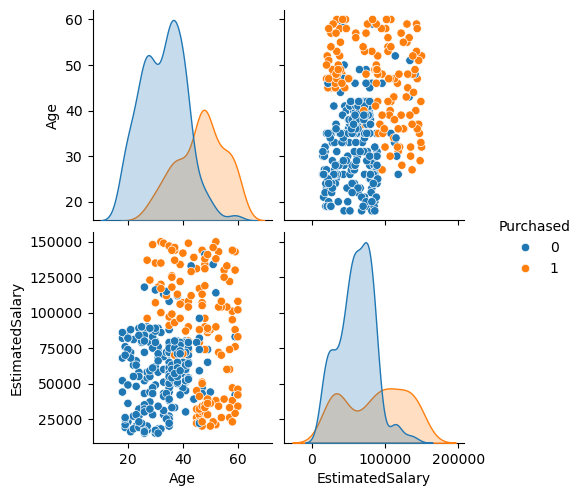

In [8]:
sns.pairplot(ads, hue='Purchased')
plt.show()

## Data Cleaning / Preprocessing

In [10]:
ads.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [13]:
X = ads.drop('Purchased', axis=1)
y = ads['Purchased']

## Training a Logistic Regression Model

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

In [15]:
logmodel = LogisticRegression(max_iter=1000)
logmodel.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Predictions

In [16]:
predictions = logmodel.predict(X_test)
predictions[:10]

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0])

## Evaluation

In [17]:
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.825


In [18]:
print(confusion_matrix(y_test, predictions))

[[72  8]
 [13 27]]


In [19]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87        80
           1       0.77      0.68      0.72        40

    accuracy                           0.82       120
   macro avg       0.81      0.79      0.80       120
weighted avg       0.82      0.82      0.82       120



## Conclusion
The Logistic Regression model predicts whether a user purchased a product based on age and estimated salary.  
The dataset was already clean and numerical, so no categorical encoding was needed.